<a href="https://colab.research.google.com/github/202422/Startup-Operational-Status-prediction-using-Machine-learning/blob/work_branch/Modelling/Multiclass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import joblib

In [2]:
df = pd.read_csv("company_feat_eng_df.csv")

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df.head(15)

,status,isClosed,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
0,3,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597,-0.065070,0.154780,-0.151095,0.218221,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706,0.011392,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970,0.011392,0.722506,-0.151095,2.189171,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759,0.011392,0.722506,-0.151095,2.189171,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,3,0,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739,-0.250311,-0.129084,-0.151095,0.236260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3,0,0.678003,-0.369189,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-1.067472,-0.250311,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,1.942436,0.011392,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,3,0,0.258618,0.049336,-0.392899,-0.291683,0.384564,-0.553941,-1.116427,-0.366961,-0.514252,-1.067472,0.012759,0.438643,-0.151095,0.618435,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,3,0,0.887539,-0.611010,-0.392899,-0.291683,0.384564,1.355647,1.773511,5.295752,0.138444,-0.488618,-0.542295,-0.696810,-0.151095,2.404255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,3,0,-0.581405,0.710249,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.542930,-0.412942,0.154780,-0.151095,0.218221,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
x = df.drop(["status"], axis = 1)
y = df[["status"]]

In [6]:
x

,isClosed,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
0,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597,-0.065070,0.154780,-0.151095,0.218221,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706,0.011392,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970,0.011392,0.722506,-0.151095,2.189171,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759,0.011392,0.722506,-0.151095,2.189171,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739,-0.250311,-0.129084,-0.151095,0.236260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44073,0,-0.371242,0.562082,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.281636,-0.208669,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
44074,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,1.058366,-0.387278,0.011392,-0.129084,-0.151095,0.236260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
44075,0,-0.791673,0.849809,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.342299,-0.672770,0.154780,-0.151095,0.218221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
44076,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,1.992176,1.773511,2.138829,1.058366,-1.067472,-0.065070,-0.696810,-0.151095,3.533147,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Multiclass Classification
## A. Oversampling and spliting
## B. Training models
      1. AdaBoostClassifier
      2. GradientBoostingClassifier


## A. Oversampling and spliting


In [7]:
y.value_counts()

,count
status,
3,41393
0,1783
1,802
2,100


In [8]:
# Oversampling
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

In [9]:
y_resampled.value_counts()

,count
status,
0,41393
1,41393
2,41393
3,41393


In [10]:
x_resampled

,isClosed,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
0,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597,-0.065070,0.154780,-0.151095,0.218221,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706,0.011392,0.154780,-0.151095,0.218221,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970,0.011392,0.722506,-0.151095,2.189171,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759,0.011392,0.722506,-0.151095,2.189171,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739,-0.250311,-0.129084,-0.151095,0.236260,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165567,0,-1.930032,1.483385,-0.392899,-0.291683,0.384564,1.992176,1.773511,0.648265,1.523031,0.114404,-2.868168,-0.696810,-0.151095,3.533147,0.0,0.594848,0.0,0.0,0.0,0.0,0.0,0.405152,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
165568,0,-3.363791,2.090529,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.046079,-0.403765,-7.048264,0.154780,-0.151095,0.218221,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
165569,0,-2.900135,1.912482,-0.392899,-1.225971,-0.961081,1.551775,1.273640,-0.366961,0.488721,-0.842382,-5.546456,-0.500411,0.377607,2.074441,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.691879,0.308121,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
165570,0,-2.489662,1.740740,-0.392899,-0.291683,0.384564,0.070475,-0.393942,-0.366961,0.605153,2.600898,-4.336932,0.154780,-0.151095,-0.027763,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [11]:
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size = 0.2)

In [12]:
x_train

,isClosed,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,category_code_web,country_code_AUS,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
141449,0,-0.581405,0.710249,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.375066,0.260593,-0.412942,0.154780,-0.151095,0.218221,0.0,0.467384,0.0,0.0,0.0,0.0,0.000000,0.532616,0.00000,0.0,0.00000,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.0,0.467384,0.0,0.532616,0.0
52589,1,0.887539,-5.650097,-0.392899,-0.291683,0.384564,1.355647,1.051027,-0.366961,-1.434174,-1.067477,-5.014683,-0.412947,-0.151095,1.424821,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.007730,0.00000,0.0,0.99227,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.0,1.000000,0.0
3890,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-1.010812,0.011392,0.154780,-0.151095,0.218221,1.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.0,1.000000,0.0
28020,0,0.258618,0.049336,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,1.988599,0.012759,0.154780,-0.151095,0.218221,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.0,1.00000,0.0,0.0,0.00000,0.0,0.000000,0.000000,1.0,0.000000,0.0,0.000000,0.0
40932,0,0.468363,-0.150411,-0.392899,-0.291683,0.384564,1.992176,1.773511,-0.366961,0.138444,-0.329194,-0.070447,-0.696810,-0.151095,3.533147,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.0,1.00000,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.0,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86044,1,0.468363,-5.086015,-0.392899,-0.291683,0.384564,0.082588,-0.393942,-0.366961,-1.104102,0.789803,-2.382100,0.154780,-0.151095,-0.032535,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.0,1.00000,0.0,0.0,0.00000,0.0,0.358804,0.641196,0.0,0.000000,0.0,0.000000,0.0
133118,0,-0.131417,0.346599,1.024846,2.409044,0.038474,-0.553941,-0.848126,-0.366961,-0.514252,-0.754075,-0.241819,-0.694891,-0.338427,0.469812,0.0,0.371359,0.0,0.0,0.0,0.0,0.628641,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.0,1.000000,0.0
79609,1,-1.940764,0.629652,-0.392899,-0.291683,0.384564,1.299683,1.773511,2.138829,1.413407,-0.165901,-1.229758,-0.696810,-0.151095,2.305002,0.0,0.456040,0.0,0.0,0.0,0.0,0.000000,0.000000,0.54396,0.0,0.00000,0.0,0.0,0.45604,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.543960,0.0
18596,0,0.258618,0.049336,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-1.434174,-1.059434,0.012759,0.154780,-0.151095,0.218221,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.0,1.00000,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.0,1.000000,0.0


In [13]:
y_train.value_counts()

,count
status,
2,33166
1,33142
3,33100
0,33049


In [14]:
y_test.value_counts()

,count
status,
0,8344
3,8293
1,8251
2,8227



## B. Training models
  1. **AdaBoostClassifier**
      

In [15]:
model_ada = AdaBoostClassifier()
paramgrid_ada = {
    'n_estimators': [200],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator': [DecisionTreeClassifier(max_depth=3)]
}
grid_ada = GridSearchCV(model_ada,paramgrid_ada, cv = 5)

In [16]:
grid_ada.fit(x_train,np.ravel(y_train))

GridSearchCV(cv=5, estimator=AdaBoostClassifier(),
             param_grid={'estimator': [DecisionTreeClassifier(max_depth=3)],
                         'learning_rate': [0.01, 0.1, 1.0],
                         'n_estimators': [200]})

In [17]:
grid_ada.best_params_

{'estimator': DecisionTreeClassifier(max_depth=3),
 'learning_rate': 0.1,
 'n_estimators': 200}

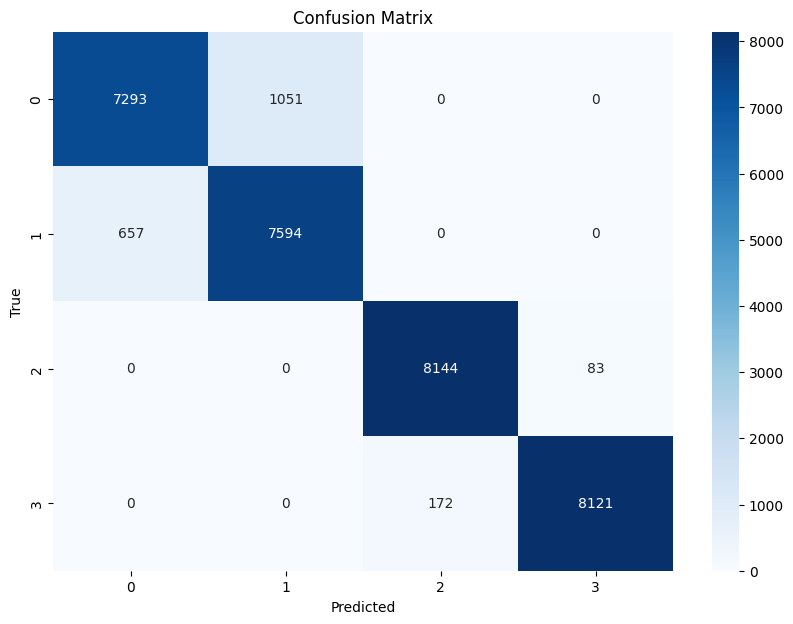

In [18]:
# Matrice de confusion
conf_matrix = confusion_matrix(y_test, grid_ada.best_estimator_.predict(x_test))
plt.figure(figsize = (10,7))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Blues", xticklabels = ["0","1","2","3"], yticklabels = ["0","1","2","3"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [19]:
# Rapport de classification
class_report = classification_report(y_test, grid_ada.best_estimator_.predict(x_test))
print(class_report)

              precision    recall  f1-score   support

           0       0.92      0.87      0.90      8344
           1       0.88      0.92      0.90      8251
           2       0.98      0.99      0.98      8227
           3       0.99      0.98      0.98      8293

    accuracy                           0.94     33115
   macro avg       0.94      0.94      0.94     33115
weighted avg       0.94      0.94      0.94     33115



In [21]:
joblib.dump(grid_ada.best_estimator_, "Ada_Boost_Multiclass.pkl")

['Ada_Boost_Multiclass.pkl']

2. **GradientBoostingClassifier**

In [22]:
model_gd = GradientBoostingClassifier()
paramgrid_gd = {
    'n_estimators': [300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [5, 7]
}
grid_gd = GridSearchCV(model_gd,paramgrid_gd, cv = 5)

In [ ]:
grid_gd.fit(x_train,np.ravel(y_train))

In [ ]:
grid_gd.best_params_

In [ ]:
# Matrice de confusion
conf_matrix_2 = confusion_matrix(y_test, grid_gd.best_estimator_.predict(x_test))
plt.figure(figsize = (10,7))
sns.heatmap(conf_matrix_2, annot = True, fmt = 'd', cmap = "Blues", xticklabels = ["0","1","2","3"], yticklabels = ["0","1","2","3"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Rapport de classification
class_report = classification_report(y_test, grid_gd.best_estimator_.predict(x_test))
print(class_report)